In [1]:
import numpy as np 
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
data = pd.read_csv(r'C:\Users\yanis\neural-network\neural-network\train.csv')

In [3]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # Shuffle rows in place so the training/dev split is random

# Set aside examples not used for trining (validation/dev set)
data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255. # Rescales the pixels to a range between 0 & 1

# Training data
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255. # Rescales the pixels to a range between 0 & 1
_, m_train = X_train.shape # _ = number of features/rows (784 after transpose), m_train = number of examples

In [5]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 41000))

In [6]:
Y_train.shape

(41000,)

In [7]:
X_train[:,0].shape

(784,)

In [8]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5 # generates a matrix filled with random numbers (weights)
    b1 = np.random.rand(10, 1)- 0.5
    W2 = np.random.rand(10, 10) - 0.5 
    b2 = np.random.rand(10, 1)- 0.5
    return W1, b1, W2, b2

# Apply ReLu elementwise to Z1
def Relu(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1 
    A1 = Relu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

# Return an elementwise mask of Z > 0 for the ReLU derivative
def deriv_Relu(Z): 
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1 # Build one-hot labels: each column is a class vector for one example
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y # Output error vector for softmax output
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * deriv_Relu(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1) 
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2    

In [9]:
def get_predictions(A2):
    return np.argmax(A2, 0) # Return predicted class index for each column/example 

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size # Fraction of predictions that are correct

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:  # print traning progress every iteration
            print('Iteration: ', i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2


In [10]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)
print("finished")

Iteration:  0
[0 1 1 ... 9 7 1] [5 6 9 ... 2 5 2]
0.08024390243902439
Iteration:  10
[0 0 0 ... 9 3 4] [5 6 9 ... 2 5 2]
0.23087804878048782
Iteration:  20
[0 0 0 ... 9 6 4] [5 6 9 ... 2 5 2]
0.3172439024390244
Iteration:  30
[0 0 0 ... 9 0 4] [5 6 9 ... 2 5 2]
0.3701951219512195
Iteration:  40
[0 0 0 ... 9 5 4] [5 6 9 ... 2 5 2]
0.41273170731707315
Iteration:  50
[0 0 4 ... 9 5 4] [5 6 9 ... 2 5 2]
0.4573658536585366
Iteration:  60
[0 0 4 ... 2 5 4] [5 6 9 ... 2 5 2]
0.4994878048780488
Iteration:  70
[0 0 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.5416341463414635
Iteration:  80
[0 0 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.5819756097560975
Iteration:  90
[0 5 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.6130243902439024
Iteration:  100
[0 5 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.6349268292682927
Iteration:  110
[0 5 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.6539268292682927
Iteration:  120
[5 5 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.6712926829268293
Iteration:  130
[5 5 9 ... 2 5 4] [5 6 9 ... 2 5 2]
0.6849268292682927
Iteration:  14

In [11]:
# Function that returns predictions from the network 
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_predictions(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    predictions = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Predictions: ", predictions)
    print("Label", label)
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray() 
    plt.imshow(current_image, interpolation='nearest') # Display image with no interpolation smoothing
    plt.show()

Predictions:  [3]
Label 3


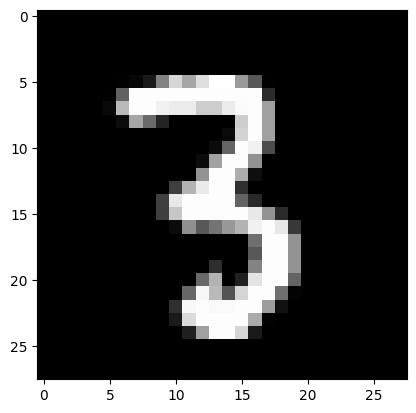

Predictions:  [7]
Label 7


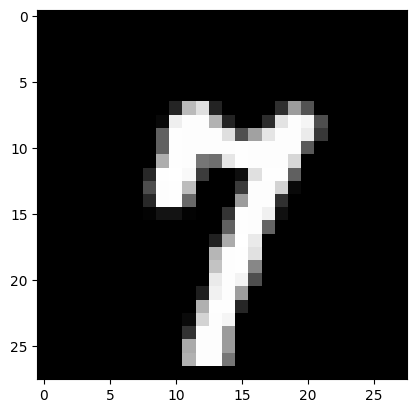

Predictions:  [6]
Label 6


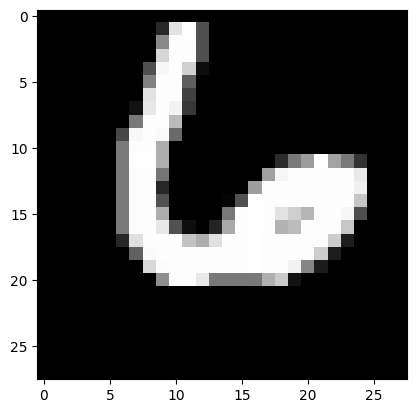

Predictions:  [6]
Label 6


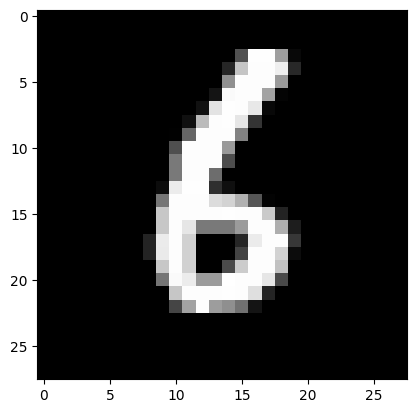

In [12]:
test_predictions(5, W1, b1, W2, b2)
test_predictions(40090, W1, b1, W2, b2)
test_predictions(40080, W1, b1, W2, b2)
test_predictions(40001, W1, b1, W2, b2)